# FX Pairs: Feasibility Analysis

`config/setup.yaml` declares a cross-sectional currency strategy: which pairs trade, when
positions change, what crossing costs, how the sample is split. This notebook asks whether the
data supports it, and fits nothing.

## Learning objectives

- Count a universe at the snapshot the strategy acts on, and read what fraction of moves clears
  cost off an exceedance curve scaled by each entity's own round trip
- Separate the number of entities from the number of independent bets they carry
- Confirm the declared folds fit the sample without touching the holdout

## Book reference

Chapter 6, Sections 6.2-6.6. Reads OANDA FX bars and `config/setup.yaml`, never writes.

## Prerequisites

Polars for frame work, and the walk-forward cross-validation vocabulary from Chapter 6: training
window, validation window, purge gap, holdout. No model fitting is needed to follow this.

In [1]:
"""FX Pairs Case Study - Feasibility Analysis."""

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import yaml
from ml4t.diagnostic.splitters.calendar import TradingCalendar

from case_studies.utils.feasibility import exceedance_curve, fold_timeline, panel_acf
from data import load_fx_pairs
from utils.cv_splits import generate_cv_splits
from utils.paths import get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title, ml4t_palette

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "fx_pairs"
START_DATE = "2011-01-01"
END_DATE = "2025-12-31"

## Configuration

Every knob is read from `setup.yaml`, and Section B computes on the development window alone, so
nothing the holdout contains can shape a choice made here. Two calendars are declared and they
answer different questions: `decision.session_calendar` is the venue whose rollover decides which
session a four-hour bar belongs to, which is what this notebook needs to find each day's close,
while `evaluation.calendar` is the one the splitter counts train and validation windows on.

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
SETUP = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

HOLDOUT_START = str(SETUP["evaluation"]["holdout_start"])
HOLDOUT_END = str(SETUP["evaluation"]["holdout_end"])
DECLARED_PAIRS = sorted(SETUP["universe"]["symbols"])
PRIMARY_LABEL = SETUP["labels"]["primary"]
HORIZONS = sorted(int(n.split("_")[-1][:-1]) for n in [PRIMARY_LABEL, *SETUP["labels"]["variants"]])
PRIMARY_HORIZON = int(PRIMARY_LABEL.split("_")[-1][:-1])
BREADTH_FLOOR = 2 * max(SETUP["backtest"]["sweep"]["top_k_grid"][PRIMARY_LABEL])
SPREAD_BPS = SETUP["costs"]["spread_bps"]
SESSION_CALENDAR = SETUP["decision"]["session_calendar"]

print(f"Development {START_DATE} to {HOLDOUT_START} | sealed holdout to {HOLDOUT_END}")
print(f"{len(DECLARED_PAIRS)} pairs, floor {BREADTH_FLOOR} | horizons {HORIZONS} sessions")

Development 2011-01-01 to 2024-01-01 | sealed holdout to 2025-12-31
20 pairs, floor 20 | horizons [1, 5, 21] sessions


## A. Orientation

A currency pair is a relative price, so a long position is always a short in the quote currency
and the cross-section is a set of differences rather than a set of assets. The market trades
around the clock on weekdays and has no exchange close, which leaves the trading day a convention
that `setup.yaml::decision.snapshot` picks. Three questions decide whether a ranking strategy is
worth building here: does the universe quote at the snapshot, is a move large next to a round
trip, and are there enough decision dates?

## B. Universe and cost feasibility

### B.1 Load and verify the declared universe

The loader returns four-hour bars and positions change once a day, so the calendar assigns each
bar to its session first, which puts the bars after the New York rollover into the next session
rather than the one whose date they carry. The session's last bar across the universe is the one
the decision reads, and a pair enters the panel only where it has that bar: its own last bar
would fill a missing close with a stale earlier one.

In [4]:
bars = load_fx_pairs(start_date=START_DATE, end_date=END_DATE)
calendar = TradingCalendar(SESSION_CALENDAR)
sessions = calendar.get_sessions(pd.DatetimeIndex(bars["timestamp"].to_pandas()))
bars = bars.with_columns(pl.Series("session", sessions.values).cast(pl.Date)).drop_nulls("session")

research = bars.filter(pl.col("session") < pl.lit(HOLDOUT_START).str.to_date())
decision_bar = research.group_by("session").agg(pl.col("timestamp").max().alias("timestamp"))
daily = research.join(decision_bar, on=["session", "timestamp"]).sort(["symbol", "session"])

missing = sorted(set(DECLARED_PAIRS) - set(daily["symbol"].unique().to_list()))
assert not missing, f"declared in setup.yaml but absent from the data: {missing}"
print(
    f"{daily['symbol'].n_unique()} pairs, {len(daily):,} session closes, "
    f"{daily['session'].min()} to {daily['session'].max()}"
)

20 pairs, 67,100 session closes, 2011-01-03 to 2023-12-29


### B.2 Breadth at every decision date

A both-leg book holding the declared number of pairs on each side needs the whole universe present
on the date it rebalances, which the four-hour grid an alternative cadence trades does not.

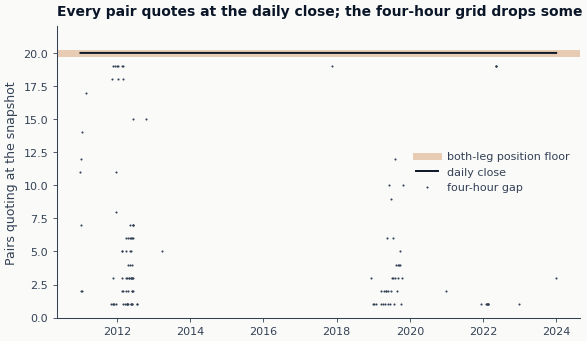

In [5]:
snap = daily.group_by("session").agg(pl.col("symbol").n_unique().alias("n")).sort("session")
grid = research.group_by("timestamp").agg(pl.col("symbol").n_unique().alias("n")).sort("timestamp")

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
gaps = grid.filter(pl.col("n") < BREADTH_FLOOR)
# The floor sits exactly on the daily-close series, since a both-leg book of the declared size
# needs all twenty pairs.
floor = dict(color=COLORS["copper"], lw=5, alpha=0.35, zorder=1)
ax.axhline(BREADTH_FLOOR, label="both-leg position floor", **floor)
ax.plot(snap["session"], snap["n"], color=COLORS["blue"], lw=1.4, label="daily close", zorder=3)
ax.plot(gaps["timestamp"], gaps["n"], ".", ms=3, color=COLORS["neutral"], label="four-hour gap")
ax.set_ylim(0, len(DECLARED_PAIRS) + 2)
ax.set_ylabel("Pairs quoting at the snapshot")
ax.legend(frameon=False, fontsize=8, loc="center right")
add_message_title(ax, "Every pair quotes at the daily close; the four-hour grid drops some")
plt.show()

Nominal breadth is not the breadth a portfolio gets. Every pair shares a currency leg with
several others, so returns move together and the cross-section carries fewer independent bets
than it has members. The participation ratio of the correlation eigenvalues,
$(\sum_i \lambda_i)^2 / \sum_i \lambda_i^2$, equals the number of pairs when they are
independent and one when they are identical.

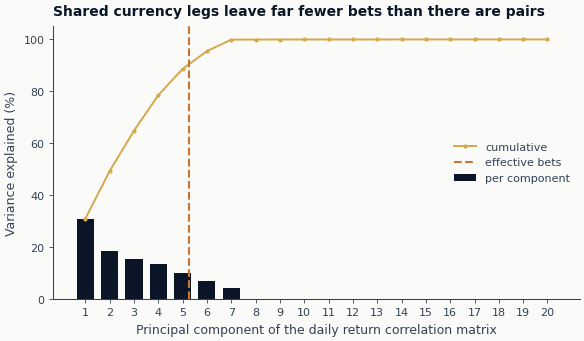

In [6]:
returns = daily.with_columns(pl.col("close").pct_change().over("symbol").alias("ret"))
wide = returns.select("symbol", "session", "ret").pivot(index="session", on="symbol", values="ret")
spectrum = np.corrcoef(wide.drop("session").drop_nulls().to_numpy(), rowvar=False)
eigenvalues = np.sort(np.linalg.eigvalsh(spectrum))[::-1]
share = eigenvalues / eigenvalues.sum()
participation = float(eigenvalues.sum() ** 2 / (eigenvalues**2).sum())

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
pc = np.arange(1, len(share) + 1)
ax.bar(pc, share * 100, color=COLORS["blue"], width=0.7, label="per component")
ax.plot(pc, np.cumsum(share) * 100, "o-", color=COLORS["amber"], lw=1.4, ms=3, label="cumulative")
ax.axvline(participation, color=COLORS["copper"], ls="--", lw=1.5, label="effective bets")
ax.set_xlabel("Principal component of the daily return correlation matrix")
ax.set_ylabel("Variance explained (%)")
ax.set_xticks(pc)
ax.legend(frameon=False, fontsize=8, loc="center right")
add_message_title(ax, "Shared currency legs leave far fewer bets than there are pairs")
plt.show()

### B.3 What a round trip costs, and what a move is worth

`setup.yaml::costs` prices a trade as a spread band per leg: one band for the pairs quoted against
the dollar and a wider one for the crosses, which are quoted through it. A round trip pays a leg
in and a leg out, and the top of each band is the conservative end to charge yourself. This data
carries no quotes, so nothing here is measured - the declared assumption is what gets drawn.

7 pairs at 6 bps | 13 pairs at 16 bps | universe median 16 bps


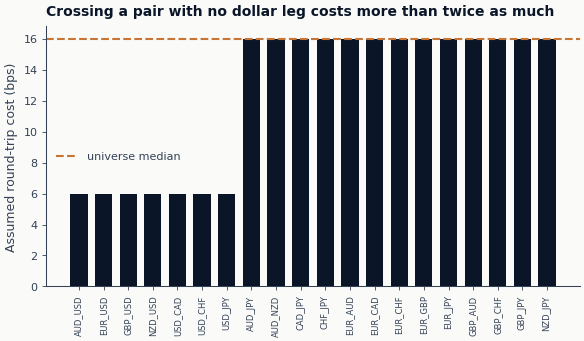

In [7]:
cost = (
    pl.DataFrame({"symbol": DECLARED_PAIRS})
    .with_columns(
        pl.when(pl.col("symbol").str.contains("USD"))
        .then(2 * SPREAD_BPS["major_pairs"][-1])
        .otherwise(2 * SPREAD_BPS["cross_pairs"][-1])
        .alias("cost_bps")
    )
    .sort(["cost_bps", "symbol"])
)
COST_BPS = float(cost["cost_bps"].median())
by_class = cost.group_by("cost_bps").len().sort("cost_bps").rows()
tiers = " | ".join(f"{n} pairs at {bps} bps" for bps, n in by_class)
print(f"{tiers} | universe median {COST_BPS:.0f} bps")

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.bar(cost["symbol"], cost["cost_bps"], color=COLORS["blue"], width=0.7)
ax.axhline(COST_BPS, color=COLORS["copper"], ls="--", lw=1.5, label="universe median")
ax.set_ylabel("Assumed round-trip cost (bps)")
ax.tick_params(axis="x", labelsize=6, rotation=90)
ax.legend(frameon=False, fontsize=8, loc="center left")
add_message_title(ax, "Crossing a pair with no dollar leg costs more than twice as much")
plt.show()

Cost differs across the universe, so one cost line on raw returns answers the question for no
pair in particular. Each move is divided by its own pair's round trip instead, which puts
break-even at one and lets every candidate horizon sit on one axis.

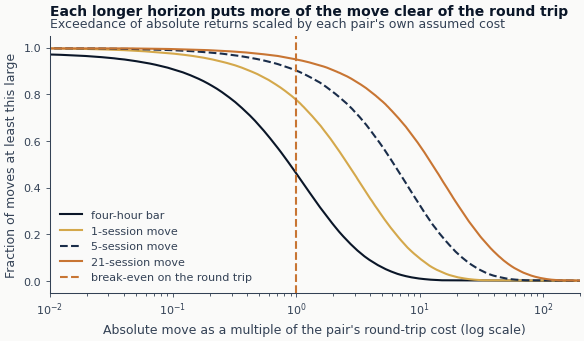

In [8]:
moves = (
    daily.with_columns(
        pl.col("close").pct_change(h).abs().over("symbol").alias(f"h{h}") for h in HORIZONS
    )
    .join(cost, "symbol")
    .with_columns(pl.col(f"h{h}") * 1e4 / pl.col("cost_bps") for h in HORIZONS)
)
spacing = pl.col("timestamp").diff().over("symbol") == pl.duration(hours=4)
intraday = (
    research.sort(["symbol", "timestamp"])
    .with_columns(pl.col("close").pct_change().abs().over("symbol").alias("bar"))
    .filter(spacing)
    .join(cost, "symbol")
    .with_columns(pl.col("bar") * 1e4 / pl.col("cost_bps"))
)
curves = [("four-hour bar", intraday["bar"])]
curves += [(f"{h}-session move", moves[f"h{h}"]) for h in HORIZONS]

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
palette = ml4t_palette(len(curves), categorical=True)
for (label, series), color, style in zip(curves, palette, ("-", "-", "--", "-"), strict=True):
    magnitude, fraction = exceedance_curve(series.drop_nulls().to_numpy())
    ax.plot(magnitude, fraction, color=color, ls=style, lw=1.5, label=label)
ax.axvline(1, color=COLORS["copper"], ls="--", lw=1.5, label="break-even on the round trip")
ax.set(xscale="log", xlim=(0.01, 200))
ax.set_xlabel("Absolute move as a multiple of the pair's round-trip cost (log scale)")
ax.set_ylabel("Fraction of moves at least this large")
ax.legend(frameon=False, fontsize=8, loc="lower left")
add_message_title(
    ax,
    "Each longer horizon puts more of the move clear of the round trip",
    subtitle="Exceedance of absolute returns scaled by each pair's own assumed cost",
)
plt.show()

### B.4 How long the carrier stays put

`setup.yaml::mapping.entry_logic` ranks pairs on momentum or carry, both read off the return
series. How much one session of it carries on its own is an autocorrelation, computed inside each
pair and averaged, since stacking twenty and correlating measures their joins instead. It bounds
the raw series, not a feature built over many sessions - Chapter 8 builds those, Chapter 7 tests
them; the shading spans the per-pair curves and the band is white noise.

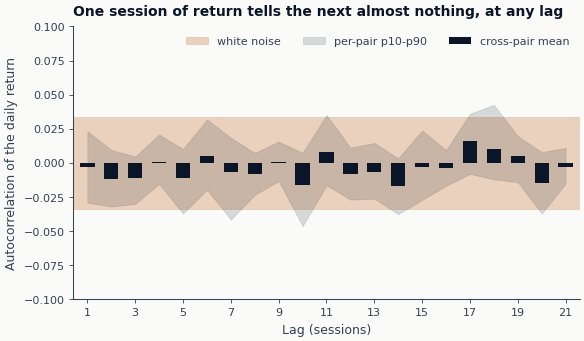

In [9]:
acf = panel_acf(returns, entity_col="symbol", value_col="ret", max_lags=max(HORIZONS))
acf = acf.filter(pl.col("lag") > 0)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
band, spread = dict(alpha=0.3, zorder=1), dict(alpha=0.15, zorder=2)
ax.axhspan(-acf["band"][0], acf["band"][0], color=COLORS["copper"], label="white noise", **band)
ax.fill_between(
    acf["lag"],
    acf["acf_p10"],
    acf["acf_p90"],
    color=COLORS["blue"],
    label="per-pair p10-p90",
    **spread,
)
ax.bar(acf["lag"], acf["acf"], color=COLORS["blue"], width=0.6, zorder=3, label="cross-pair mean")
ax.set(xlim=(0.4, max(HORIZONS) + 0.6), ylim=(-0.1, 0.1))
ax.set_xticks(range(1, max(HORIZONS) + 1, 2))
ax.set_xlabel("Lag (sessions)")
ax.set_ylabel("Autocorrelation of the daily return")
ax.legend(frameon=False, fontsize=8, loc="upper right", ncol=3)
add_message_title(ax, "One session of return tells the next almost nothing, at any lag")
plt.show()

### B.5 Move scale against cost

The ratio divides the median absolute move at the primary horizon by the median round trip, and
the clearance share counts moves above their own pair's cost. Neither says total cost clears.

In [10]:
primary = f"h{PRIMARY_HORIZON}"
cleared = moves.drop_nulls(primary)
median_move_bps = float((cleared[primary] * cleared["cost_bps"]).median())
clears_cost = float((cleared[primary] > 1).mean())
clears_intraday = float((intraday["bar"].drop_nulls() > 1).mean())
print(
    f"Round-trip cost {cost['cost_bps'].min()} to {cost['cost_bps'].max()} bps, median "
    f"{COST_BPS:.0f} bps | median {PRIMARY_HORIZON}-session move {median_move_bps:.1f} bps, "
    f"ratio {median_move_bps / COST_BPS:.1f}x, over its own pair's round trip {clears_cost:.3f}"
    f" | four-hour moves over it {clears_intraday:.3f}"
)

Round-trip cost 6 to 16 bps, median 16 bps | median 1-session move 31.3 bps, ratio 2.0x, over its own pair's round trip 0.776 | four-hour moves over it 0.461


The assumed round trip is 6 bps on the seven pairs quoted against the dollar and 16 bps on
the thirteen crosses, a median of 16 bps. The median absolute one-session move is 31.3 bps,
2.0 times that median, and 0.776 of one-session moves exceed the cost their own pair would
charge. At the four-hour bar that share falls to 0.461.

## C. Design decisions

### C.1 Cadence

`setup.yaml::decision.cadence` rebalances at the daily close and executes on the next bar's
open. B.3 supports that horizon over the alternative: a four-hour move clears its round trip
about as often as not where a one-session move clears it far more often, and B.2 shows the
four-hour grid dropping pairs the close keeps.

### C.2 Kill conditions

Three findings would send the strategy back to the drawing board, tested where the evidence
exists rather than here: a reversal information coefficient no better at any horizon than the
baseline floor `02_labels` measures; a signal explained entirely by the dollar factor, which
would make the cross-sectional ranking a directional bet; and a sign that flips across
consecutive folds.

### C.3 Mapping class

`setup.yaml::mapping.class` ranks pairs and holds both legs. A pair is already a relative price,
so the short side carries no borrow and costs what the long side costs, and B.2 is the reason to
use it: with the independent bets already well below the number of pairs, dropping a leg would
halve what little breadth there is. Sizing is equal-weight because it assumes least; the
alternatives sweep in `setup.yaml::backtest.sweep.allocators`.

## D. Walk-forward structure

### D.1 Effective sample size

What evaluation spends is decision dates, not rows. The calendar says how many sessions the
development window holds, and the panel is complete when every pair closes on each of them.

In [11]:
expected = calendar.trading_days_between(pd.Timestamp(START_DATE), pd.Timestamp(HOLDOUT_START))
print(
    f"Calendar sessions {expected:,} | observed {daily['session'].n_unique():,} "
    f"| pair-sessions {len(daily):,} of {expected * len(DECLARED_PAIRS):,}"
)

Calendar sessions 3,355 | observed 3,355 | pair-sessions 67,100 of 67,100


### D.2 Fold demonstration

`generate_cv_splits` reads the fold count and window lengths from `setup.yaml::evaluation` and
the purge width from `setup.yaml::labels.buffer`, and numbers the folds backwards from the most
recent, so they are sorted here before they are drawn. Between each training and validation block
it leaves a gap, which stops a label computed on the last training date from resolving inside
validation.

The gap is set by the label the folds are generated for. `labels.buffer` is one session,
matching the one-session `fwd_ret_1d`, so the design below covers that label exactly. The two
variants declare their own gaps in `setup.yaml::labels.variant_buffers` - five sessions for
`fwd_ret_5d`, twenty-one for `fwd_ret_21d` - and every stage that generates folds resolves the
buffer for the label it is about to train on, so each label gets its own set of boundaries. The
timeline below is therefore the primary label's design, not one design shared by all three.

The width is a scalar, and a bar a single session wide is invisible on a fifteen-year axis, so
it is printed rather than read off the figure below.

purge [1] session(s) at each of 8 boundaries, from labels.buffer 1D | last validation 2023-12-28, holdout opens 2024-01-01, 1 session between them


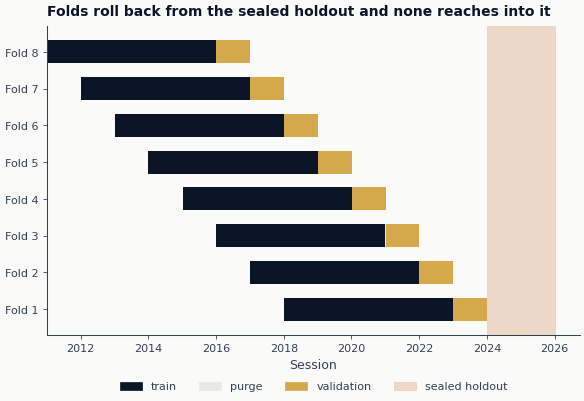

In [12]:
splits = generate_cv_splits(
    daily.select(pl.col("session").alias("timestamp")).unique().sort("timestamp"),
    case_study_id=CASE_STUDY_ID,
    label_buffer=SETUP["labels"]["buffer"],
    date_col="timestamp",
)
splits = sorted(splits, key=lambda split: split["val_start"])
last_val = max(split["val_end"] for split in splits)
assert len(splits) == SETUP["evaluation"]["n_splits"], "fold count differs from setup.yaml"
assert last_val < np.datetime64(HOLDOUT_START), "a fold reaches into the holdout"

session_grid = pd.DatetimeIndex(sorted(daily["session"].unique().to_list()))
purge = {
    int(
        session_grid.searchsorted(pd.Timestamp(s["val_start"]))
        - session_grid.searchsorted(pd.Timestamp(s["train_end"]))
        - 1
    )
    for s in splits
}
to_holdout = int(
    session_grid.searchsorted(pd.Timestamp(HOLDOUT_START)) - session_grid.searchsorted(last_val) - 1
)
print(
    f"purge {sorted(purge)} session(s) at each of {len(splits)} boundaries, from "
    f"labels.buffer {SETUP['labels']['buffer']} | last validation {pd.Timestamp(last_val).date()}, "
    f"holdout opens {HOLDOUT_START}, {to_holdout} session between them"
)

fig, ax = plt.subplots(figsize=FIGSIZE["single_tall"])
fold_timeline(ax, splits, holdout=(HOLDOUT_START, HOLDOUT_END))
ax.set_xlabel("Session")
add_message_title(ax, "Folds roll back from the sealed holdout and none reaches into it")
plt.show()

## E. Derived artifacts

Nothing is written here. The universe is fixed and declared in `setup.yaml::universe.symbols`,
which is where this notebook reads it and where a later stage that needs the list reads it too.

## F. Findings vs `setup.yaml`

| Knob | Evidence | Revise it when |
|---|---|---|
| `universe.symbols` | B.2 breadth and participation ratio | a pair stops quoting at the close, or the independent bets fall further |
| `decision.cadence` | B.2 breadth by snapshot, B.3 exceedance | a shorter horizon starts clearing its round trip on a grid that carries the whole universe |
| `costs.spread_bps` | B.3 the declared band, drawn per pair | spreads estimated from quotes sit outside the band |
| `evaluation.n_splits` | D.1 session count, D.2 boundaries | the folds no longer fit the development window |

In [13]:
print(
    f"universe.n_assets {SETUP['universe']['n_assets']}, breadth per decision date "
    f"{snap['n'].min()} to {snap['n'].max()}, under the floor on "
    f"{snap.filter(pl.col('n') < BREADTH_FLOOR).height} of {len(snap)} dates, effective bets "
    f"{participation:.1f}\ndecision.cadence {SETUP['decision']['cadence']} | labels.primary "
    f"{PRIMARY_LABEL} | costs.spread_bps per leg major {SPREAD_BPS['major_pairs']} cross "
    f"{SPREAD_BPS['cross_pairs']}\nevaluation.n_splits {SETUP['evaluation']['n_splits']}, "
    f"generated {len(splits)}, last validation ends {last_val.date()}, holdout untouched"
)

universe.n_assets 20, breadth per decision date 20 to 20, under the floor on 0 of 3355 dates, effective bets 5.3
decision.cadence daily_ny_close | labels.primary fwd_ret_1d | costs.spread_bps per leg major [1, 3] cross [3, 8]
evaluation.n_splits 8, generated 8, last validation ends 2023-12-28, holdout untouched


All twenty pairs quote on every one of the 3,355 decision dates, so the floor of twenty
never binds, but the correlation spectrum puts the effective independent bets at 5.3. Eight
folds are generated, the last validation ending 2023-12-28.

## Key takeaways

1. **Count the universe at the snapshot the strategy acts on**, and take the close from that bar:
   a pair's own last bar fills a missing close with a stale earlier one.
2. **Count the independent bets, not the entities.** Where members share a risk factor, the
   participation ratio of the correlation spectrum is the breadth a portfolio actually gets.
3. **Scale each move by its own entity's cost before comparing horizons**, so one axis answers
   what fraction of moves clears the round trip.
4. **Compute a panel autocorrelation inside each entity**, never across the stack, which would
   measure the joins between entities instead.

### Known limitations

- Cost here is the declared spread alone. Swap points accrue on every position held overnight, and
  both enter at the cost stage, which is where the band is tested against estimated spreads.
- The band is an assumption: a pair whose realized spread sits outside it does not show up here.

**Next**: labels at the declared horizons, built on this development window.